# 02. Ingeniería de características en cinco cortes temporales
Objetivo específico 2; CRISP-DM: preparación. Se implementan los cortes 7, 14, 28,
42 y 56 adoptados por el usuario para esta versión. No se presume un acta de
aprobación institucional. Cada ventana acumulada incluye el día 0 y el día del corte.
La función compartida `src/ventanas_oulad.py` evita mantener cinco implementaciones
distintas. Las fuentes, filtros, fórmulas y comprobaciones permanecen explícitos.


In [1]:
import os, sys, json
from pathlib import Path
candidate = Path(os.environ.get('OULAD_ROOT', Path.cwd())).resolve()
ROOT = next(p for p in [candidate, *candidate.parents] if (p / 'data/raw/studentInfo.csv').exists())
sys.path.insert(0, str(ROOT / 'src'))
from oulad_revision import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', 40)
print(environment())


{'python': '3.11.9', 'packages': {'pandas': '2.3.3', 'numpy': '2.4.4', 'scipy': '1.17.1', 'matplotlib': '3.10.9', 'scikit-learn': '1.8.0', 'pyarrow': '24.0.0'}}


## 1. Protocolo y trazabilidad
Para un corte t, la elegibilidad exige matrícula conocida <=t, ausencia de retiro
<=t y final de presentación >t. La etiqueta es 1 cuando t<retiro<=final. Se supone
cobertura administrativa hasta el final; no se demuestra seguimiento individual.
La ausencia de fecha no equivale a permanencia educativa demostrada. Las fechas de
retiro y el resultado final permanecen separados. La información de puntajes es
retrospectiva porque no consta su fecha de publicación.


In [2]:
from ventanas_oulad import build_at_cut, eligible_at, PREDICTORS, CONTEXT, DEFINITIONS
decision=json.loads((ROOT/'decision_temporal.json').read_text(encoding='utf-8'))
CUTS=decision['cortes'];print(decision)
manifest=json.loads((OUT/'fuentes.json').read_text(encoding='utf-8'))
assert all(sha256(RAW/f'{n}.csv')==r['sha256'] for n,r in manifest.items())
base=pd.read_parquet(PROCESSED/'base_auditoria.parquet')
daily=pd.read_parquet(PROCESSED/'actividad_diaria.parquet')
sa=pd.read_parquet(PROCESSED/'entregas_metadatos.parquet')
assessments=load('assessments')


{'version': 'correcciones_2026_09_10', 'estado': 'adoptada_para_esta_version_por_el_usuario', 'evidencia': 'El usuario solicitó proceder después de la propuesta de cortes 7, 14, 28, 42 y 56 y de la explicación del protocolo de observación hasta el cierre de cada corte.', 'aprobacion_institucional': 'No se aporta acta ni se presume aprobación adicional de la dirección.', 'cortes': [7, 14, 28, 42, 56], 'ventana_acumulada': '0 <= date <= corte; incluye el día 0: corte + 1 días de calendario', 'elegibilidad': 'date_registration conocida y <= corte; date_unregistration ausente o > corte; module_presentation_length > corte', 'evento': 'corte < date_unregistration <= module_presentation_length', 'horizonte': 'Hasta final de presentación; variable entre presentaciones y decreciente al aumentar el corte', 'seguimiento': 'Se supone cobertura administrativa hasta el final; no verificable individualmente con fecha de última comprobación', 'cambio_respecto_version_anterior': 'Se mantiene población,

## 2. Variables comparables y periodos recientes
Se agregan clics y entregas en 0..t. El denominador de días activos es t+1 y
representa calendario, no tiempo individual desde matrícula; esa exposición se
conserva por separado. La recencia se ancla en t. La variabilidad incluye ceros en
todos los días. Los bloques semanales completos se cuentan desde 0 y omiten el
bloque final parcial.

La tendencia reciente compara dos bloques consecutivos de igual duración, terminados
en t. Se calculan razones logarítmicas suavizadas de 7 y 14 días; requieren al menos
14 y 28 días de historia, respectivamente. Si falta historia o ambos bloques no
tienen clics, el indicador permanece ausente. No se inventa una tendencia en el
corte 7. Los indicadores de inactividad reciente tampoco se extrapolan a periodos
no observados. La identidad entre cantidades normalizadas y absolutas se documenta
para evitar su inclusión redundante en modelos lineales.

Las entregas excluyen Exam y banked; el denominador de evaluaciones usa el calendario
de cada presentación. La proporción entregada no mide puntualidad. Los puntajes y su
número de observaciones se mantienen solo para auditoría.

El conteo de filas se conserva solo para auditoría. Se añade CV entre días activos, no observable con menos de dos días, sin sustituir retrospectivamente el CV de calendario. Diversidad no se incorpora en esta versión; su aporte queda sin evaluar.


In [3]:
datasets={};flows=[];population=[];courses_rows=[];availability=[];indicators=[]
for cut in CUTS:
    d,flow=build_at_cut(base,daily,sa,assessments,int(cut));datasets[cut]=d;flows.append(flow)
    population.append({'corte':cut,'dias_observados':cut+1,'inscripciones':len(d),
      'personas':d.id_student.nunique(),'retiros':int(d.retiro_futuro.sum()),
      'prevalencia_pct':100*d.retiro_futuro.mean(),
      'sin_actividad':int(d.sin_actividad_acumulada.sum()),
      'sin_evaluacion_programada':int(d.sin_evaluacion_programada.sum()),
      'con_entregas':int(d.n_evaluaciones_entregadas.gt(0).sum()),
      'matricula_posterior_inicio':int(d.date_registration.gt(0).sum()),
      'horizonte_min':d.horizonte_restante.min(),'horizonte_max':d.horizonte_restante.max()})
    bycourse=d.groupby(COURSE,observed=True).agg(inscripciones=('id_student','size'),
      personas=('id_student','nunique'),retiros=('retiro_futuro','sum'),
      evaluaciones_programadas=('n_evaluaciones_programadas','first')).reset_index()
    bycourse['corte']=cut;courses_rows.append(bycourse)
    for v in PREDICTORS:
        availability.append({'corte':cut,'variable':v,'n':len(d),'observadas':int(d[v].notna().sum()),
          'faltantes':int(d[v].isna().sum()),'porcentaje_observado':100*d[v].notna().mean(),
          'valores_distintos':d[v].nunique()})
    for span in [7,14,28]:
        s=d[f'sin_actividad_ultimos_{span}d'];inact=s.eq(1)
        indicators.append({'corte':cut,'dias_sin_actividad':span,'n_observable':int(s.notna().sum()),
          'inactivas':int(inact.sum()),'retiros_entre_inactivas':int(d.loc[inact,'retiro_futuro'].sum()),
          'tasa_retiro_pct':100*d.loc[inact,'retiro_futuro'].mean()})
    d.to_parquet(PROCESSED/f'dataset_corte_{cut:02d}.parquet',index=False)
    d[KEY+['corte']+PREDICTORS].to_parquet(PROCESSED/f'predictores_corte_{cut:02d}.parquet',index=False)
    d[KEY+['corte','retiro_futuro']].to_parquet(PROCESSED/f'objetivo_corte_{cut:02d}.parquet',index=False)
population=pd.DataFrame(population)
table('02_comparacion_cortes',population)
table('02_flujos',pd.concat(flows,ignore_index=True))
table('02_por_presentacion',pd.concat(courses_rows,ignore_index=True))
table('02_disponibilidad',pd.DataFrame(availability))
table('02_inactividad',pd.DataFrame(indicators))


02_comparacion_cortes
 corte  dias_observados  inscripciones  personas  retiros  prevalencia_pct  sin_actividad  sin_evaluacion_programada  con_entregas  matricula_posterior_inicio  horizonte_min  horizonte_max
     7                8          29076     26030     6632        22.809190           5316                      29076           772                         140            227            262
    14               15          28054     25220     5580        19.890212           2551                      26765          3226                         173            220            255
    28               29          27515     24826     5012        18.215519           1203                       4988         19849                         208            206            241
    42               43          27005     24491     4500        16.663581            918                       2426         22276                         210            192            227
    56               57          

## 3. Cambio de composición y comparación con la versión anterior
Las poblaciones no son idénticas: salen inscripciones por retiro y pueden entrar
matrículas registradas después de cortes previos. Se exportan intersecciones y
transiciones. La muestra común a los cinco cortes se utiliza solo como análisis
complementario condicionado a seguir elegible hasta 56; no representa la población
original ni valida capacidad de anticipación.

El corte 28 actual incorpora los registros del día 28, a diferencia de la versión
anterior. Una tabla de enlace separa ese cambio de definición de una supuesta mejora
del análisis. Los resultados previos permanecen conservados.


02_transiciones
 desde  hasta  comunes  salen  entran
     7     14    28019   1057      35
    14     28    27477    577      38
    28     42    27001    514       4
    42     56    26503    502       3
Filas inscripción-corte: 138156 Personas distintas: 26089 Inscripciones comunes: 26429
02_enlace_corte28
                 variable  inscripciones_comparadas  suma_anterior  suma_actual  inscripciones_con_cambio
              total_clics                     27515      7603586.0    7766285.0                      7993
n_evaluaciones_entregadas                     27515        22870.0      23136.0                       263


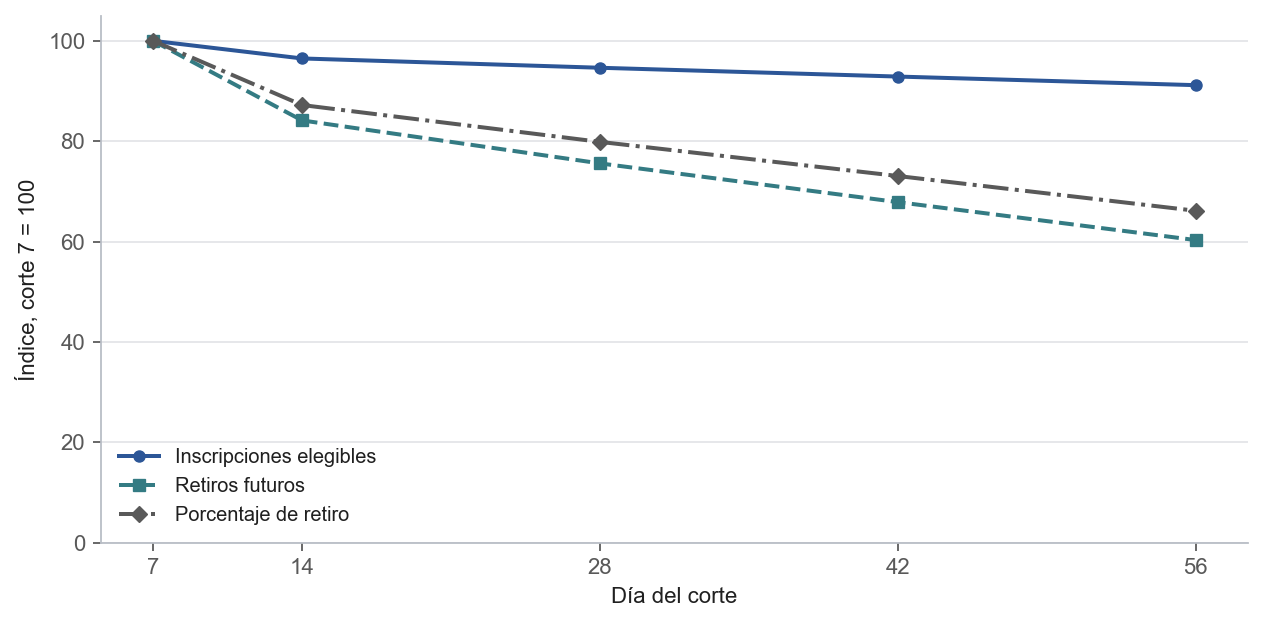

In [4]:
transitions=[]
for previous,current in zip(CUTS[:-1],CUTS[1:]):
    ka=keyset(datasets[previous],KEY);kb=keyset(datasets[current],KEY)
    transitions.append({'desde':previous,'hasta':current,'comunes':len(ka&kb),
                        'salen':len(ka-kb),'entran':len(kb-ka)})
table('02_transiciones',pd.DataFrame(transitions))
common=set.intersection(*(keyset(datasets[t],KEY) for t in CUTS))
common_frame=pd.DataFrame(sorted(common),columns=KEY)
common_frame.to_parquet(PROCESSED/'inscripciones_comunes.parquet',index=False)
stack=pd.concat(datasets.values(),ignore_index=True)
assert not stack.duplicated(KEY+['corte']).any()
stack.to_parquet(PROCESSED/'dataset_multiventana.parquet',index=False)
print('Filas inscripción-corte:',len(stack),'Personas distintas:',stack.id_student.nunique(),
      'Inscripciones comunes:',len(common))
oldpath=ROOT/'data/processed/revision_2026_09_08/dataset_analitico_corregido.parquet'
if oldpath.exists():
    old=pd.read_parquet(oldpath);new=datasets[28]
    bridge=old[KEY+['total_clics','n_evaluaciones_entregadas']].merge(
        new[KEY+['total_clics','n_evaluaciones_entregadas']],on=KEY,validate='one_to_one',suffixes=('_anterior','_actual'))
    table('02_enlace_corte28',pd.DataFrame([{'variable':v,'inscripciones_comparadas':len(bridge),
      'suma_anterior':bridge[v+'_anterior'].sum(),'suma_actual':bridge[v+'_actual'].sum(),
      'inscripciones_con_cambio':int(bridge[v+'_anterior'].ne(bridge[v+'_actual']).sum())}
      for v in ['total_clics','n_evaluaciones_entregadas']]))
from figuras_oulad import poblacion_cortes
poblacion_cortes(population)
figure('02_poblacion_cortes')


## 4. Diccionario y conservación de límites
Los nombres de variables son estables entre cortes. La columna corte identifica la
observación y no es una recomendación de predictor. Las filas apiladas no son
observaciones independientes y no deben dividirse aleatoriamente para modelado.
Se exportan archivos por corte y se conserva la persona como clave para un futuro
protocolo de validación. No se seleccionan particiones ni modelos en esta fase.


In [5]:
dictionary=[]
for v in stack.columns:
    role=('identificador' if v in KEY+['corte'] else 'objetivo' if v=='retiro_futuro' else
          'predictor_candidato' if v in PREDICTORS else 'contexto_condicionado' if v in CONTEXT else 'auditoria_no_predictor')
    definition,domain=DEFINITIONS.get(v,('Campo de fuente o auditoría; no usar automáticamente para predicción','Según fuente y contrato'))
    dictionary.append({'variable':v,'rol':role,'definicion':definition,'dominio':domain})
table('02_diccionario',pd.DataFrame(dictionary))
save_json('02_resumen.json',{'decision':decision,'cortes':CUTS,'filas_inscripcion_corte':len(stack),
 'personas_distintas':int(stack.id_student.nunique()),'inscripciones_distintas':int(stack[KEY].drop_duplicates().shape[0]),
 'inscripciones_comunes':len(common),'predictores':PREDICTORS,'contexto_condicionado':CONTEXT})
save_json('productos_02.json',{p.name:sha256(p) for p in PROCESSED.glob('*.parquet') if p.name.startswith(('dataset_','predictores_','objetivo_','inscripciones_comunes'))})
save_json('decision_temporal.json',decision)
print('Cinco cortes exportados y verificados. No se utilizaron puntajes como predictores.')


02_diccionario
                         variable                    rol                                                                definicion                                           dominio
                      code_module          identificador      Campo de fuente o auditoría; no usar automáticamente para predicción                           Según fuente y contrato
                code_presentation          identificador      Campo de fuente o auditoría; no usar automáticamente para predicción                           Según fuente y contrato
                       id_student          identificador      Campo de fuente o auditoría; no usar automáticamente para predicción                           Según fuente y contrato
                date_registration auditoria_no_predictor      Campo de fuente o auditoría; no usar automáticamente para predicción                           Según fuente y contrato
              date_unregistration auditoria_no_predictor      Campo de fuente o 